# Imports and File Path Setup

In [56]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
import math 

import dask.array as da 
from tifffile import imwrite


In [108]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src'

# Change this variable to the directory where all your data is. Don't remove the r
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny'
#base_dir = r'C:\Users\Kenny\akamatsu'
# Change this variable to the current data you are analyzing in your base_dir.
input_file_directory = 'lumenoid_2_analysis/'

In [109]:
# Visualizing the detections in Napari
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
filtered_tracks_treatment = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

## AP2 Histogram Lifetimes

In [110]:
###### Set the following variables #######


# Background intensity for each channel

background_channel_1 = 240
background_channel_2 = 150
background_channel_3 = 170

# framerate (in milliseconds)

framerate_msec = 2500

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [111]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [112]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [113]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [114]:
# region_to_plot = 'Apical'
# region_to_plot = 'Lateral'
# region_to_plot = 'Basal'
region_to_plot = 'All'

if region_to_plot == 'All':
    #filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()

if region_to_plot != 'All':
   # filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()
   # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
    filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

In [120]:
plot_all_channels = False
channels_to_plot = [True, True]
if plot_all_channels:
   # tracks_channel_subset_control = filtered_tracks_all_control.copy()
    tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
else:
    channels_to_plot = channels_to_plot

   # tracks_channel_subset_control = filtered_tracks_all_control[(filtered_tracks_all_control['channel1_positive'] == channels_to_plot[0]) &
   #                                 (filtered_tracks_all_control['channel2_positive'] == channels_to_plot[1])]

    tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) &
                                        (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
# else:
#     tracks_channel_subset_control = filtered_tracks_all_control[filtered_tracks_all_control['channel2_positive'] == True]
#     tracks_channel_subset_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['channel2_positive'] == True]

In [ ]:
# ## seperating the regions into different variables

# tracks_apical = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Apical']
# tracks_lateral = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Lateral']
# tracks_basal = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Basal']

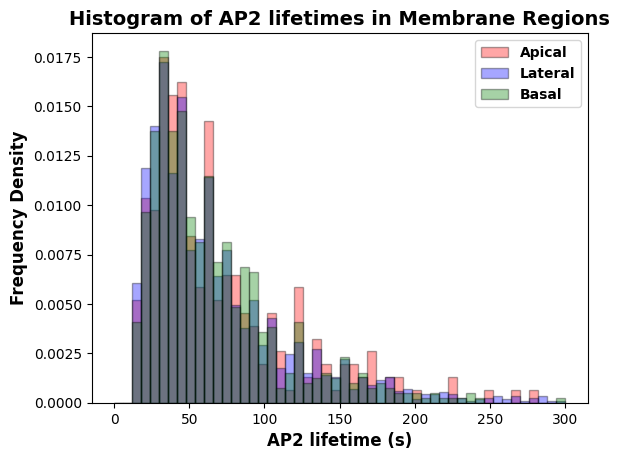

In [ ]:
# # Plot histogram of all track lengths (lifetimes)

# # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
# #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
# #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
# all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
# all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
# all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000

# # Plot histograms of membrane regions 
# # on the same plot with 50 bins, and different colors
# bins = np.linspace(0, 300, 51)  # Define the bin edges
# plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
# plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
# plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
# plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
# plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
# plt.title('Histogram of AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram


# plt.legend(prop = {'weight':'bold'})
# plt.show()

In [ ]:
# Plot histogram of all track lengths (lifetimes)
def createHistogramAP2Lifetimes(tracks):
    tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
    tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
    tracks_basal = tracks[tracks['membrane_region'] == 'Basal']

    # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
    #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
    #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
    all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
    all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
    all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
    bins = np.linspace(0, 300, 51)  # Define the bin edges
    plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
    plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
    plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
    plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
    plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
    plt.title(f'Histogram of AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    plt.legend(prop = {'weight':'bold'})
    plt.show()

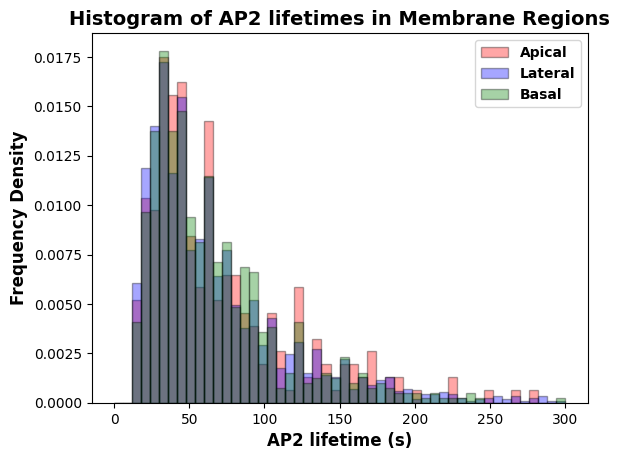

In [126]:
createHistogramAP2Lifetimes(tracks_channel_subset_treatment)

## Box and Whisker plots of AP2 lifetimes in Membrane Regions

In [ ]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
# region_to_plot = 'Apical'
# region_to_plot = 'Lateral'
# region_to_plot = 'Basal'
region_to_plot = 'All'

if region_to_plot == 'All':
    #filtered_tracks_all_control = filtered_tracks_control.copy()
    compare_lumenoid_filtered_tracks_all_treatment = compare_lumenoid_df.copy()

if region_to_plot != 'All':
   # filtered_tracks_all_control = filtered_tracks_control.copy()
    compare_lumenoid_filtered_tracks_all_treatment = compare_lumenoid_df.copy()
   # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
    compare_lumenoid_filtered_tracks_all_treatment = compare_lumenoid_df[compare_lumenoid_df['membrane_region'] == region_to_plot]

plot_all_channels = False
channels_to_plot = [True, True]
if plot_all_channels:
   # tracks_channel_subset_control = filtered_tracks_all_control.copy()
    compare_lumenoid_tracks_channel_subset_treatment = compare_lumenoid_filtered_tracks_all_treatment.copy()
else:
    channels_to_plot = channels_to_plot

   # tracks_channel_subset_control = filtered_tracks_all_control[(filtered_tracks_all_control['channel1_positive'] == channels_to_plot[0]) &
   #                                 (filtered_tracks_all_control['channel2_positive'] == channels_to_plot[1])]

    compare_lumenoid_tracks_channel_subset_treatment = compare_lumenoid_filtered_tracks_all_treatment[(compare_lumenoid_filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) &
                                        (compare_lumenoid_filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
# else:
#     tracks_channel_subset_control = filtered_tracks_all_control[filtered_tracks_all_control['channel2_positive'] == True]
#     tracks_channel_subset_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['channel2_positive'] == True]
## seperating the regions into different variables

tracks_apical = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Apical']
tracks_lateral = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Lateral']
tracks_basal = tracks_channel_subset_treatment[tracks_channel_subset_treatment['membrane_region'] == 'Basal']